In [51]:
import pandas as pd
import seaborn as sns
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import GroupShuffleSplit
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import FunctionTransformer
from sklearn.dummy import DummyClassifier
from sklearn.model_selection import GroupKFold
from sklearn.model_selection import cross_validate
from sklearn.metrics import make_scorer, precision_score, recall_score, f1_score
from sklearn.base import clone
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier


In [2]:
df=pd.read_csv("hotel_bookings.csv")
print("Dataset shape:", df.shape)
df.head()

Dataset shape: (119390, 32)


,hotel,is_canceled,lead_time,arrival_date_year,arrival_date_month,arrival_date_week_number,arrival_date_day_of_month,stays_in_weekend_nights,stays_in_week_nights,adults,...,deposit_type,agent,company,days_in_waiting_list,customer_type,adr,required_car_parking_spaces,total_of_special_requests,reservation_status,reservation_status_date
0,Resort Hotel,0,342,2015,July,27,1,0,0,2,...,No Deposit,NaN,NaN,0,Transient,0.0,0,0,Check-Out,2015-07-01
1,Resort Hotel,0,737,2015,July,27,1,0,0,2,...,No Deposit,NaN,NaN,0,Transient,0.0,0,0,Check-Out,2015-07-01
2,Resort Hotel,0,7,2015,July,27,1,0,1,1,...,No Deposit,NaN,NaN,0,Transient,75.0,0,0,Check-Out,2015-07-02
3,Resort Hotel,0,13,2015,July,27,1,0,1,1,...,No Deposit,304.0,NaN,0,Transient,75.0,0,0,Check-Out,2015-07-02
4,Resort Hotel,0,14,2015,July,27,1,0,2,2,...,No Deposit,240.0,NaN,0,Transient,98.0,0,1,Check-Out,2015-07-03


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 119390 entries, 0 to 119389
Data columns (total 32 columns):
 #   Column                          Non-Null Count   Dtype  
---  ------                          --------------   -----  
 0   hotel                           119390 non-null  object 
 1   is_canceled                     119390 non-null  int64  
 2   lead_time                       119390 non-null  int64  
 3   arrival_date_year               119390 non-null  int64  
 4   arrival_date_month              119390 non-null  object 
 5   arrival_date_week_number        119390 non-null  int64  
 6   arrival_date_day_of_month       119390 non-null  int64  
 7   stays_in_weekend_nights         119390 non-null  int64  
 8   stays_in_week_nights            119390 non-null  int64  
 9   adults                          119390 non-null  int64  
 10  children                        119386 non-null  float64
 11  babies                          119390 non-null  int64  
 12  meal            

In [4]:
missing_values =df.isna().sum()
print("missing Vlues:")
print(missing_values[missing_values>0])
print("\nreapeted values:",df.duplicated().sum())

missing Vlues:
children         4
country        488
agent        16340
company     112593
dtype: int64

reapeted values: 31994


In [5]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
is_canceled,119390.0,0.370416,0.482918,0.00,0.00,0.000,1.0,1.0
lead_time,119390.0,104.011416,106.863097,0.00,18.00,69.000,160.0,737.0
arrival_date_year,119390.0,2016.156554,0.707476,2015.00,2016.00,2016.000,2017.0,2017.0
arrival_date_week_number,119390.0,27.165173,13.605138,1.00,16.00,28.000,38.0,53.0
arrival_date_day_of_month,119390.0,15.798241,8.780829,1.00,8.00,16.000,23.0,31.0
stays_in_weekend_nights,119390.0,0.927599,0.998613,0.00,0.00,1.000,2.0,19.0
stays_in_week_nights,119390.0,2.500302,1.908286,0.00,1.00,2.000,3.0,50.0
adults,119390.0,1.856403,0.579261,0.00,2.00,2.000,2.0,55.0
children,119386.0,0.103890,0.398561,0.00,0.00,0.000,0.0,10.0
babies,119390.0,0.007949,0.097436,0.00,0.00,0.000,0.0,10.0


In [6]:
display(df.describe(include="object").T)
print("unique values per column:")
print(df.nunique().sort_values())

,count,unique,top,freq
hotel,119390,2,City Hotel,79330
arrival_date_month,119390,12,August,13877
meal,119390,5,BB,92310
country,118902,177,PRT,48590
market_segment,119390,8,Online TA,56477
distribution_channel,119390,5,TA/TO,97870
reserved_room_type,119390,10,A,85994
assigned_room_type,119390,12,A,74053
deposit_type,119390,3,No Deposit,104641
customer_type,119390,4,Transient,89613


unique values per column:
hotel                                2
is_canceled                          2
is_repeated_guest                    2
arrival_date_year                    3
deposit_type                         3
reservation_status                   3
customer_type                        4
required_car_parking_spaces          5
meal                                 5
babies                               5
distribution_channel                 5
children                             5
total_of_special_requests            6
market_segment                       8
reserved_room_type                  10
arrival_date_month                  12
assigned_room_type                  12
adults                              14
previous_cancellations              15
stays_in_weekend_nights             17
booking_changes                     21
arrival_date_day_of_month           31
stays_in_week_nights                35
arrival_date_week_number            53
previous_bookings_not_canceled      73

In [7]:
df.columns

Index(['hotel', 'is_canceled', 'lead_time', 'arrival_date_year',
       'arrival_date_month', 'arrival_date_week_number',
       'arrival_date_day_of_month', 'stays_in_weekend_nights',
       'stays_in_week_nights', 'adults', 'children', 'babies', 'meal',
       'country', 'market_segment', 'distribution_channel',
       'is_repeated_guest', 'previous_cancellations',
       'previous_bookings_not_canceled', 'reserved_room_type',
       'assigned_room_type', 'booking_changes', 'deposit_type', 'agent',
       'company', 'days_in_waiting_list', 'customer_type', 'adr',
       'required_car_parking_spaces', 'total_of_special_requests',
       'reservation_status', 'reservation_status_date'],
      dtype='object')

In [8]:
target_summary = pd.DataFrame({"booking_count": df["is_canceled"].value_counts(),"percentage":
(df["is_canceled"].value_counts(normalize=True).mul(100).round(2))}).sort_index()
target_summary.index.name = "is_canceled"
target_summary

,booking_count,percentage
is_canceled,,
0,75166,62.96
1,44224,37.04


In [9]:
print("Children counts:")
print(df["children"].value_counts(dropna=False))
print("\nBooking counts by children:")
display(df.loc[df["children"].isna(),
               ["hotel","adults","children","babies","customer_type"]])
print("\nBookings with 10 children:")
display(df.loc[
    df["children"]==10,
    ["hotel","adults","children","babies","customer_type"]
])

Children counts:
children
0.0     110796
1.0       4861
2.0       3652
3.0         76
NaN          4
10.0         1
Name: count, dtype: int64

Booking counts by children:


,hotel,adults,children,babies,customer_type
40600,City Hotel,2,NaN,0,Transient-Party
40667,City Hotel,2,NaN,0,Transient-Party
40679,City Hotel,3,NaN,0,Transient-Party
41160,City Hotel,2,NaN,0,Transient-Party



Bookings with 10 children:


,hotel,adults,children,babies,customer_type
328,Resort Hotel,2,10.0,0,Contract


In [11]:
zero_guest_mask =((df["adults"]==0)
                  &(df["children"]==0)
                  &(df["babies"]==0)
)
print("zero-guest records:", zero_guest_mask.sum())
df_clean = df.loc[~zero_guest_mask].copy()
print("Shape after filterning:", df_clean.shape)

zero-guest records: 180
Shape after filterning: (119210, 32)


In [13]:
df_model = df_clean.drop(columns=["reservation_status", "reservation_status_date"]).copy()
X = df_model.drop(columns=["is_canceled"])
y = df_model["is_canceled"]
print("Input shape:",X.shape)
print("Target shape:", y.shape)

Input shape: (119210, 29)
Target shape: (119210,)


In [14]:
print("Repeated input rows:", X.duplicated().sum())
input_groups = X.groupby(X.columns.tolist(),dropna=False).ngroup()
print("Unique input groups:", input_groups.nunique())

Repeated input rows: 32503
Unique input groups: 86707


In [15]:
splitter = GroupShuffleSplit(n_splits=1,test_size=0.20,random_state=42)
train_idx,test_idx= next(splitter.split(X,y,groups=input_groups))
X_train = X.iloc[train_idx].copy()
X_test = X.iloc[test_idx].copy()
y_train = y.iloc[train_idx].copy()
y_test =y.iloc[test_idx].copy()
print("Training shape:",X_train.shape, y_train.shape)
print("Testing shape:",X_test.shape, y_test.shape)

Training shape: (95771, 29) (95771,)
Testing shape: (23439, 29) (23439,)


In [17]:
train_groups = input_groups.iloc[train_idx]
test_groups = input_groups.iloc[test_idx]
common_groups = set(train_groups).intersection(set(test_groups))
print("common_groups:",len(common_groups))
print("train split rows:", len(X_train)+len(X_test))
assert len(common_groups) ==0
assert len(X_train) + len(X_test) == len(X)
assert X_train.index.equals(y_train.index)
assert X_test.index.equals(y_test.index)

common_groups: 0
train split rows: 119210


In [18]:
train_missing = X_train.isna().sum()

print(
    train_missing[train_missing > 0]
    .sort_values(ascending=False)
)

company     90406
agent       13024
country       392
children        3
dtype: int64


In [19]:
X_train_fe = X_train.copy()

X_train_fe["total_nights"] = (
    X_train_fe["stays_in_week_nights"]
    + X_train_fe["stays_in_weekend_nights"]
)

X_train_fe["total_guests"] = (
    X_train_fe["adults"]
    + X_train_fe["children"]
    + X_train_fe["babies"]
)

X_train_fe["has_previous_booking"] = (
    (
        X_train_fe["previous_cancellations"]
        + X_train_fe["previous_bookings_not_canceled"]
    ) > 0
).astype(int)

X_train_fe[
    ["total_nights", "total_guests", "has_previous_booking"]
].head()

,total_nights,total_guests,has_previous_booking
0,0,2.0,0
2,1,1.0,0
4,2,2.0,0
5,2,2.0,0
6,2,2.0,0


In [20]:
train_eda = X_train_fe.copy()
train_eda["is_canceled"] = y_train

train_eda.head()

,hotel,lead_time,arrival_date_year,arrival_date_month,arrival_date_week_number,arrival_date_day_of_month,stays_in_weekend_nights,stays_in_week_nights,adults,children,...,company,days_in_waiting_list,customer_type,adr,required_car_parking_spaces,total_of_special_requests,total_nights,total_guests,has_previous_booking,is_canceled
0,Resort Hotel,342,2015,July,27,1,0,0,2,0.0,...,NaN,0,Transient,0.0,0,0,0,2.0,0,0
2,Resort Hotel,7,2015,July,27,1,0,1,1,0.0,...,NaN,0,Transient,75.0,0,0,1,1.0,0,0
4,Resort Hotel,14,2015,July,27,1,0,2,2,0.0,...,NaN,0,Transient,98.0,0,1,2,2.0,0,0
5,Resort Hotel,14,2015,July,27,1,0,2,2,0.0,...,NaN,0,Transient,98.0,0,1,2,2.0,0,0
6,Resort Hotel,0,2015,July,27,1,0,2,2,0.0,...,NaN,0,Transient,107.0,0,0,2,2.0,0,0


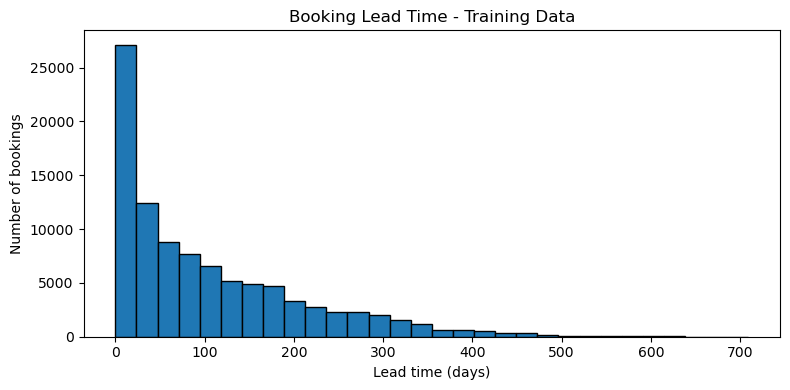

In [21]:
plt.figure(figsize=(8, 4))

plt.hist(
    train_eda["lead_time"],
    bins=30,
    edgecolor="black"
)

plt.xlabel("Lead time (days)")
plt.ylabel("Number of bookings")
plt.title("Booking Lead Time - Training Data")
plt.tight_layout()
plt.show()

In [22]:
lead_time_summary = (
    train_eda.groupby("is_canceled")["lead_time"]
    .agg(["count", "median", "mean"])
    .round(2)
)

lead_time_summary

,count,median,mean
is_canceled,,,
0,60191,46.0,80.42
1,35580,113.0,145.80


In [23]:
hotel_summary = (
    train_eda.groupby("hotel")["is_canceled"]
    .agg(
        total_bookings="count",
        cancelled_bookings="sum",
        cancellation_rate="mean"
    )
)

hotel_summary["cancellation_rate"] = (
    hotel_summary["cancellation_rate"] * 100
).round(2)

hotel_summary

,total_bookings,cancelled_bookings,cancellation_rate
hotel,,,
City Hotel,63762,26619,41.75
Resort Hotel,32009,8961,28.00


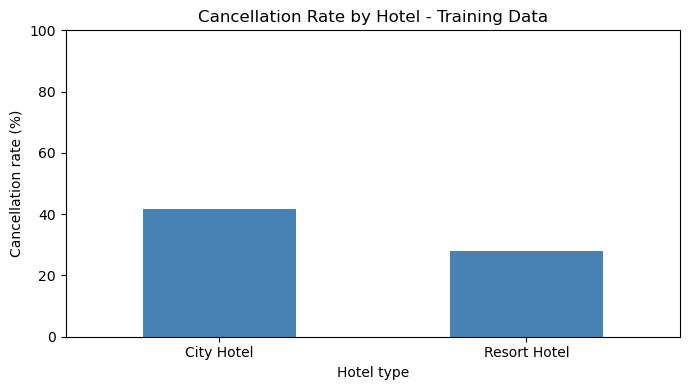

In [24]:
hotel_summary["cancellation_rate"].plot(
    kind="bar",
    color="steelblue",
    figsize=(7, 4)
)

plt.xlabel("Hotel type")
plt.ylabel("Cancellation rate (%)")
plt.title("Cancellation Rate by Hotel - Training Data")
plt.xticks(rotation=0)
plt.ylim(0, 100)
plt.tight_layout()
plt.show()

In [25]:
display(X_train["adr"].describe())

display(
    X_train.nlargest(5, "adr")[
        [
            "hotel", "adr", "adults", "children",
            "stays_in_week_nights", "stays_in_weekend_nights"
        ]
    ]
)

count    95771.000000
mean       102.003691
std         50.837533
min         -6.380000
25%         70.000000
50%         95.000000
75%        126.000000
max       5400.000000
Name: adr, dtype: float64

,hotel,adr,adults,children,stays_in_week_nights,stays_in_weekend_nights
48515,City Hotel,5400.0,2,0.0,1,0
111403,City Hotel,510.0,1,0.0,1,0
15083,Resort Hotel,508.0,2,0.0,1,0
103912,City Hotel,451.5,2,2.0,1,1
13391,Resort Hotel,437.0,2,2.0,4,2


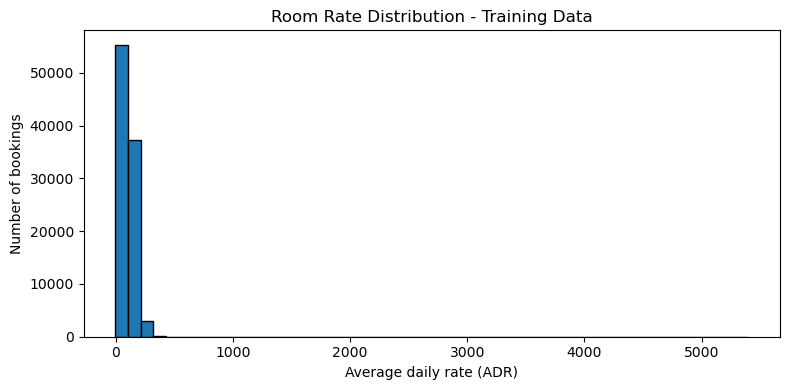

In [26]:
plt.figure(figsize=(8, 4))

plt.hist(
    X_train["adr"],
    bins=50,
    edgecolor="black"
)

plt.xlabel("Average daily rate (ADR)")
plt.ylabel("Number of bookings")
plt.title("Room Rate Distribution - Training Data")
plt.tight_layout()
plt.show()

In [27]:
negative_adr_mask = X_train["adr"] < 0

print("Negative ADR bookings:", negative_adr_mask.sum())

display(
    X_train.loc[
        negative_adr_mask,
        [
            "hotel", "adr", "adults", "children",
            "stays_in_week_nights", "stays_in_weekend_nights"
        ]
    ]
)

Negative ADR bookings: 1


,hotel,adr,adults,children,stays_in_week_nights,stays_in_weekend_nights
14969,Resort Hotel,-6.38,2,0.0,6,4


In [28]:
def clean_booking_inputs(data):
    cleaned = data.copy()

    cleaned["country"] = cleaned["country"].fillna("Unknown")

    cleaned["agent"] = (
        cleaned["agent"]
        .astype("Int64")
        .astype("string")
        .fillna("No_Agent")
    )

    cleaned["company"] = (
        cleaned["company"]
        .astype("Int64")
        .astype("string")
        .fillna("No_Company")
    )

    cleaned["adr"] = cleaned["adr"].mask(cleaned["adr"] < 0)

    return cleaned

In [29]:
X_train_prepared = clean_booking_inputs(X_train)
X_test_prepared = clean_booking_inputs(X_test)

remaining_missing = X_train_prepared.isna().sum()

print("Remaining training missing values:")
print(remaining_missing[remaining_missing > 0])

Remaining training missing values:
children    3
adr         1
dtype: int64


In [31]:
numeric_pipeline = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="median"))
    ]
)

In [32]:
numeric_columns = (
    X_train_prepared
    .select_dtypes(include="number")
    .columns.tolist()
)

categorical_columns = (
    X_train_prepared
    .select_dtypes(include=["object", "string", "category"])
    .columns.tolist()
)

print("Numerical columns:")
print(numeric_columns)

print("\nCategorical columns:")
print(categorical_columns)

Numerical columns:
['lead_time', 'arrival_date_year', 'arrival_date_week_number', 'arrival_date_day_of_month', 'stays_in_weekend_nights', 'stays_in_week_nights', 'adults', 'children', 'babies', 'is_repeated_guest', 'previous_cancellations', 'previous_bookings_not_canceled', 'booking_changes', 'days_in_waiting_list', 'adr', 'required_car_parking_spaces', 'total_of_special_requests']

Categorical columns:
['hotel', 'arrival_date_month', 'meal', 'country', 'market_segment', 'distribution_channel', 'reserved_room_type', 'assigned_room_type', 'deposit_type', 'agent', 'company', 'customer_type']


In [34]:
categorical_pipeline = Pipeline(
    steps=[
        (
            "encoder",
            OneHotEncoder(handle_unknown="ignore")
        )
    ]
)

In [36]:
preprocessor = ColumnTransformer(
    transformers=[
        ("numeric", numeric_pipeline, numeric_columns),
        ("categorical", categorical_pipeline, categorical_columns)
    ],
    remainder="drop"
)

In [38]:
baseline_pipeline = Pipeline(
    steps=[
        (
            "cleaning",
            FunctionTransformer(clean_booking_inputs, validate=False)
        ),
        ("preprocessing", preprocessor),
        (
            "model",
            DummyClassifier(strategy="most_frequent")
        )
    ]
)

In [40]:
group_cv = GroupKFold(n_splits=5)

cv_groups = input_groups.iloc[train_idx]

print("Cross-validation folds:", group_cv.get_n_splits())
print("Training rows:", len(X_train))
print("Group labels:", len(cv_groups))

assert X_train.index.equals(cv_groups.index)

Cross-validation folds: 5
Training rows: 95771
Group labels: 95771


In [42]:
scoring = {
    "accuracy": "accuracy",
    "precision": make_scorer(precision_score, zero_division=0),
    "recall": make_scorer(recall_score, zero_division=0),
    "f1": make_scorer(f1_score, zero_division=0),
    "roc_auc": "roc_auc"
}

baseline_scores = cross_validate(
    estimator=baseline_pipeline,
    X=X_train,
    y=y_train,
    groups=cv_groups,
    cv=group_cv,
    scoring=scoring,
    n_jobs=1,
    error_score="raise"
)

baseline_summary = pd.DataFrame({
    "Mean CV score": {
        metric: baseline_scores[f"test_{metric}"].mean()
        for metric in scoring
    },
    "CV standard deviation": {
        metric: baseline_scores[f"test_{metric}"].std()
        for metric in scoring
    }
}).round(4)

baseline_summary

,Mean CV score,CV standard deviation
accuracy,0.6285,0.0082
precision,0.0000,0.0000
recall,0.0000,0.0000
f1,0.0000,0.0000
roc_auc,0.5000,0.0000


In [44]:
scaled_numeric_pipeline = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler())
    ]
)

logistic_preprocessor = clone(preprocessor)

logistic_preprocessor.set_params(
    numeric=scaled_numeric_pipeline
)

,transformers,"[('numeric', ...), ('categorical', ...)]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True
,force_int_remainder_cols,'deprecated'
,missing_values,nan
,strategy,'median'
,fill_value,None


In [45]:
logistic_pipeline = Pipeline(
    steps=[
        (
            "cleaning",
            FunctionTransformer(clean_booking_inputs, validate=False)
        ),
        ("preprocessing", logistic_preprocessor),
        (
            "model",
            LogisticRegression(
                solver="liblinear",
                max_iter=1000,
                random_state=42
            )
        )
    ]
)

In [46]:
logistic_scores = cross_validate(
    estimator=logistic_pipeline,
    X=X_train,
    y=y_train,
    groups=cv_groups,
    cv=group_cv,
    scoring=scoring,
    n_jobs=1,
    error_score="raise"
)

logistic_summary = pd.DataFrame({
    "Mean CV score": {
        metric: logistic_scores[f"test_{metric}"].mean()
        for metric in scoring
    },
    "CV standard deviation": {
        metric: logistic_scores[f"test_{metric}"].std()
        for metric in scoring
    }
}).round(4)

comparison = pd.DataFrame({
    "Dummy baseline": baseline_summary["Mean CV score"],
    "Logistic Regression": logistic_summary["Mean CV score"]
})

display(logistic_summary)
display(comparison)

,Mean CV score,CV standard deviation
accuracy,0.8279,0.0039
precision,0.8091,0.0088
recall,0.7027,0.0119
f1,0.7521,0.0056
roc_auc,0.9100,0.0022


,Dummy baseline,Logistic Regression
accuracy,0.6285,0.8279
precision,0.0000,0.8091
recall,0.0000,0.7027
f1,0.0000,0.7521
roc_auc,0.5000,0.9100


In [48]:
tree_pipeline = Pipeline(
    steps=[
        (
            "cleaning",
            FunctionTransformer(clean_booking_inputs, validate=False)
        ),
        ("preprocessing", clone(preprocessor)),
        (
            "model",
            DecisionTreeClassifier(
                max_depth=8,
                min_samples_leaf=20,
                random_state=42
            )
        )
    ]
)

In [49]:
tree_scores = cross_validate(
    estimator=tree_pipeline,
    X=X_train,
    y=y_train,
    groups=cv_groups,
    cv=group_cv,
    scoring=scoring,
    n_jobs=1,
    error_score="raise"
)

tree_summary = pd.DataFrame({
    "Mean CV score": {
        metric: tree_scores[f"test_{metric}"].mean()
        for metric in scoring
    },
    "CV standard deviation": {
        metric: tree_scores[f"test_{metric}"].std()
        for metric in scoring
    }
}).round(4)

tree_summary

,Mean CV score,CV standard deviation
accuracy,0.8301,0.0029
precision,0.7923,0.0259
recall,0.7375,0.0221
f1,0.7632,0.0061
roc_auc,0.9125,0.0048


In [50]:
comparison = pd.DataFrame({
    "Dummy baseline": baseline_summary["Mean CV score"],
    "Logistic Regression": logistic_summary["Mean CV score"],
    "Decision Tree": tree_summary["Mean CV score"]
})

comparison

,Dummy baseline,Logistic Regression,Decision Tree
accuracy,0.6285,0.8279,0.8301
precision,0.0000,0.8091,0.7923
recall,0.0000,0.7027,0.7375
f1,0.0000,0.7521,0.7632
roc_auc,0.5000,0.9100,0.9125


In [52]:
forest_pipeline = Pipeline(
    steps=[
        (
            "cleaning",
            FunctionTransformer(clean_booking_inputs, validate=False)
        ),
        ("preprocessing", clone(preprocessor)),
        (
            "model",
            RandomForestClassifier(
                n_estimators=200,
                min_samples_leaf=2,
                max_features="sqrt",
                random_state=42,
                n_jobs=-1
            )
        )
    ]
)

In [53]:
forest_scores = cross_validate(
    estimator=forest_pipeline,
    X=X_train,
    y=y_train,
    groups=cv_groups,
    cv=group_cv,
    scoring=scoring,
    n_jobs=1,
    error_score="raise"
)

In [54]:
forest_summary = pd.DataFrame({
    "Mean CV score": {
        metric: forest_scores[f"test_{metric}"].mean()
        for metric in scoring
    },
    "CV standard deviation": {
        metric: forest_scores[f"test_{metric}"].std()
        for metric in scoring
    }
}).round(4)

forest_summary

,Mean CV score,CV standard deviation
accuracy,0.8516,0.0050
precision,0.8997,0.0071
recall,0.6760,0.0125
f1,0.7719,0.0079
roc_auc,0.9387,0.0020


In [55]:
from sklearn.ensemble import GradientBoostingClassifier

boosting_pipeline = Pipeline(
    steps=[
        (
            "cleaning",
            FunctionTransformer(clean_booking_inputs, validate=False)
        ),
        ("preprocessing", clone(preprocessor)),
        (
            "model",
            GradientBoostingClassifier(
                n_estimators=100,
                learning_rate=0.1,
                max_depth=3,
                random_state=42
            )
        )
    ]
)

In [56]:
boosting_scores = cross_validate(
    estimator=boosting_pipeline,
    X=X_train,
    y=y_train,
    groups=cv_groups,
    cv=group_cv,
    scoring=scoring,
    n_jobs=1,
    error_score="raise"
)

In [57]:
boosting_summary = pd.DataFrame({
    "Mean CV score": {
        metric: boosting_scores[f"test_{metric}"].mean()
        for metric in scoring
    },
    "CV standard deviation": {
        metric: boosting_scores[f"test_{metric}"].std()
        for metric in scoring
    }
}).round(4)

boosting_summary

,Mean CV score,CV standard deviation
accuracy,0.8531,0.0026
precision,0.8466,0.0100
recall,0.7383,0.0022
f1,0.7887,0.0045
roc_auc,0.9299,0.0008


In [58]:
from sklearn.ensemble import AdaBoostClassifier

adaboost_pipeline = Pipeline(
    steps=[
        (
            "cleaning",
            FunctionTransformer(clean_booking_inputs, validate=False)
        ),
        ("preprocessing", clone(preprocessor)),
        (
            "model",
            AdaBoostClassifier(
                n_estimators=100,
                learning_rate=0.1,
                random_state=42
            )
        )
    ]
)

In [59]:
adaboost_scores = cross_validate(
    estimator=adaboost_pipeline,
    X=X_train,
    y=y_train,
    groups=cv_groups,
    cv=group_cv,
    scoring=scoring,
    n_jobs=1,
    error_score="raise"
)

In [60]:
adaboost_summary = pd.DataFrame({
    "Mean CV score": {
        metric: adaboost_scores[f"test_{metric}"].mean()
        for metric in scoring
    },
    "CV standard deviation": {
        metric: adaboost_scores[f"test_{metric}"].std()
        for metric in scoring
    }
}).round(4)

adaboost_summary

,Mean CV score,CV standard deviation
accuracy,0.7513,0.0067
precision,0.9929,0.0063
recall,0.3329,0.0093
f1,0.4985,0.0106
roc_auc,0.8067,0.0065


In [61]:
model_summaries = {
    "Dummy baseline": baseline_summary,
    "Logistic Regression": logistic_summary,
    "Decision Tree": tree_summary,
    "Random Forest": forest_summary,
    "Gradient Boosting": boosting_summary,
    "AdaBoost": adaboost_summary
}

model_comparison = pd.DataFrame({
    name: summary["Mean CV score"]
    for name, summary in model_summaries.items()
}).T

model_comparison = model_comparison[
    ["accuracy", "precision", "recall", "f1", "roc_auc"]
]

model_comparison.round(4)

,accuracy,precision,recall,f1,roc_auc
Dummy baseline,0.6285,0.0000,0.0000,0.0000,0.5000
Logistic Regression,0.8279,0.8091,0.7027,0.7521,0.9100
Decision Tree,0.8301,0.7923,0.7375,0.7632,0.9125
Random Forest,0.8516,0.8997,0.6760,0.7719,0.9387
Gradient Boosting,0.8531,0.8466,0.7383,0.7887,0.9299
AdaBoost,0.7513,0.9929,0.3329,0.4985,0.8067


In [62]:
ranked_models = (
    model_comparison
    .drop(index="Dummy baseline")
    .sort_values(by="f1", ascending=False)
)

display(ranked_models.round(4))

print("Highest mean CV F1:", ranked_models.index[0])

,accuracy,precision,recall,f1,roc_auc
Gradient Boosting,0.8531,0.8466,0.7383,0.7887,0.9299
Random Forest,0.8516,0.8997,0.6760,0.7719,0.9387
Decision Tree,0.8301,0.7923,0.7375,0.7632,0.9125
Logistic Regression,0.8279,0.8091,0.7027,0.7521,0.9100
AdaBoost,0.7513,0.9929,0.3329,0.4985,0.8067


Highest mean CV F1: Gradient Boosting


In [63]:
candidate_f1 = pd.DataFrame(
    {
        "Gradient Boosting F1": boosting_scores["test_f1"],
        "Random Forest F1": forest_scores["test_f1"]
    },
    index=range(1, group_cv.get_n_splits() + 1)
)

candidate_f1.index.name = "Fold"

candidate_f1["GB minus RF"] = (
    candidate_f1["Gradient Boosting F1"]
    - candidate_f1["Random Forest F1"]
)

candidate_f1.round(4)

,Gradient Boosting F1,Random Forest F1,GB minus RF
Fold,,,
1,0.7933,0.7821,0.0112
2,0.7835,0.7627,0.0208
3,0.7875,0.7760,0.0115
4,0.7848,0.7762,0.0086
5,0.7945,0.7624,0.0322


In [64]:
print("Number of input columns:", X_train.shape[1])

for number, column in enumerate(X_train.columns, start=1):
    print(f"{number}. {column}")

engineered_features = [
    "total_nights",
    "total_guests",
    "has_previous_booking"
]

print("\nEngineered features in model inputs:")

for column in engineered_features:
    print(f"{column}: {column in X_train.columns}")

Number of input columns: 29
1. hotel
2. lead_time
3. arrival_date_year
4. arrival_date_month
5. arrival_date_week_number
6. arrival_date_day_of_month
7. stays_in_weekend_nights
8. stays_in_week_nights
9. adults
10. children
11. babies
12. meal
13. country
14. market_segment
15. distribution_channel
16. is_repeated_guest
17. previous_cancellations
18. previous_bookings_not_canceled
19. reserved_room_type
20. assigned_room_type
21. booking_changes
22. deposit_type
23. agent
24. company
25. days_in_waiting_list
26. customer_type
27. adr
28. required_car_parking_spaces
29. total_of_special_requests

Engineered features in model inputs:
total_nights: False
total_guests: False
has_previous_booking: False


In [65]:
excluded_columns = [
    "is_canceled",
    "reservation_status",
    "reservation_status_date"
]

unexpected_columns = [
    column
    for column in excluded_columns
    if column in X_train.columns
]

print("Columns that should not be in inputs:", unexpected_columns)

assert not unexpected_columns, (
    f"Remove these columns from model inputs: {unexpected_columns}"
)

print("Check passed: target and final-status columns are absent.")

Columns that should not be in inputs: []
Check passed: target and final-status columns are absent.


In [66]:
feature_review = pd.DataFrame([
    {
        "Feature": "assigned_room_type",
        "Question to verify": "Was the room assignment known at booking creation?"
    },
    {
        "Feature": "booking_changes",
        "Question to verify": "Does this count include changes after booking creation?"
    },
    {
        "Feature": "deposit_type",
        "Question to verify": "Is this the initial deposit information or an updated value?"
    },
    {
        "Feature": "adr",
        "Question to verify": "Is this the rate known at booking creation or a later value?"
    },
    {
        "Feature": "total_of_special_requests",
        "Question to verify": "Were all these requests known at booking creation?"
    },
    {
        "Feature": "required_car_parking_spaces",
        "Question to verify": "Was this requirement recorded at booking creation?"
    }
])

feature_review["Present in X_train"] = (
    feature_review["Feature"].isin(X_train.columns)
)

print(feature_review.to_string(index=False))

                    Feature                                           Question to verify  Present in X_train
         assigned_room_type           Was the room assignment known at booking creation?                True
            booking_changes      Does this count include changes after booking creation?                True
               deposit_type Is this the initial deposit information or an updated value?                True
                        adr Is this the rate known at booking creation or a later value?                True
  total_of_special_requests           Were all these requests known at booking creation?                True
required_car_parking_spaces           Was this requirement recorded at booking creation?                True


In [67]:
excluded_timing_features = [
    "assigned_room_type",
    "booking_changes",
    "deposit_type",
    "adr",
    "total_of_special_requests",
    "required_car_parking_spaces"
]

X_train_revised = X_train.drop(
    columns=excluded_timing_features
).copy()

X_test_revised = X_test.drop(
    columns=excluded_timing_features
).copy()

print("Original input columns:", X_train.shape[1])
print("Revised input columns:", X_train_revised.shape[1])

Original input columns: 29
Revised input columns: 23


In [68]:
combined_revised = pd.concat(
    [X_train_revised, X_test_revised],
    axis=0
)

revised_groups = combined_revised.groupby(
    combined_revised.columns.tolist(),
    dropna=False
).ngroup()

revised_train_groups = revised_groups.loc[
    X_train_revised.index
]

revised_test_groups = revised_groups.loc[
    X_test_revised.index
]

overlap_mask = revised_train_groups.isin(
    revised_test_groups
)

print(
    "Training rows with inputs also present in test:",
    overlap_mask.sum()
)

Training rows with inputs also present in test: 4988


In [69]:
keep_train_mask = ~overlap_mask

X_train_revised = X_train_revised.loc[
    keep_train_mask
].copy()

y_train_revised = y_train.loc[
    X_train_revised.index
].copy()

cv_groups_revised = revised_train_groups.loc[
    X_train_revised.index
].copy()

y_test_revised = y_test.copy()

remaining_overlap = set(cv_groups_revised).intersection(
    set(revised_test_groups)
)

assert len(remaining_overlap) == 0
assert X_train_revised.index.equals(y_train_revised.index)
assert X_train_revised.index.equals(cv_groups_revised.index)

print("Revised training shape:", X_train_revised.shape)
print("Revised testing shape:", X_test_revised.shape)
print("Remaining overlapping groups:", len(remaining_overlap))

Revised training shape: (90783, 23)
Revised testing shape: (23439, 23)
Remaining overlapping groups: 0


In [70]:
def clean_revised_inputs(data):
    cleaned = data.copy()

    cleaned["country"] = cleaned["country"].fillna("Unknown")

    for column, label in [
        ("agent", "No_Agent"),
        ("company", "No_Company")
    ]:
        cleaned[column] = (
            cleaned[column]
            .astype("Int64")
            .astype("string")
            .fillna(label)
        )

    return cleaned

In [71]:
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

categorical_columns_revised = (
    X_train_revised
    .select_dtypes(include=["object", "string", "category"])
    .columns.tolist()
)

for column in ["agent", "company"]:
    if column not in categorical_columns_revised:
        categorical_columns_revised.append(column)

numeric_columns_revised = [
    column for column in X_train_revised.columns
    if column not in categorical_columns_revised
]

preprocessor_revised = ColumnTransformer(
    transformers=[
        (
            "numeric",
            SimpleImputer(strategy="median"),
            numeric_columns_revised
        ),
        (
            "categorical",
            OneHotEncoder(handle_unknown="ignore"),
            categorical_columns_revised
        )
    ]
)

print("Numerical columns:", len(numeric_columns_revised))
print("Categorical columns:", len(categorical_columns_revised))

Numerical columns: 13
Categorical columns: 10


In [72]:
from sklearn.preprocessing import FunctionTransformer
from sklearn.ensemble import GradientBoostingClassifier

gb_revised_pipeline = Pipeline(
    steps=[
        (
            "cleaning",
            FunctionTransformer(
                clean_revised_inputs,
                validate=False
            )
        ),
        (
            "preprocessing",
            preprocessor_revised
        ),
        (
            "model",
            GradientBoostingClassifier(
                n_estimators=100,
                learning_rate=0.1,
                max_depth=3,
                random_state=42
            )
        )
    ]
)

print("Revised Gradient Boosting pipeline is ready.")

Revised Gradient Boosting pipeline is ready.


In [73]:
from sklearn.model_selection import GridSearchCV

param_grid = {
    "model__n_estimators": [100, 150],
    "model__max_depth": [2, 3]
}

print("Number of combinations: 4")

Number of combinations: 4


In [74]:
gb_search = GridSearchCV(
    estimator=gb_revised_pipeline,
    param_grid=param_grid,
    scoring=scoring,
    refit="f1",
    cv=group_cv,
    n_jobs=1,
    verbose=1,
    error_score="raise"
)

gb_search.fit(
    X_train_revised,
    y_train_revised,
    groups=cv_groups_revised
)

Fitting 5 folds for each of 4 candidates, totalling 20 fits


,estimator,Pipeline(step...m_state=42))])
,param_grid,"{'model__max_depth': [2, 3], 'model__n_estimators': [100, 150]}"
,scoring,"{'accuracy': 'accuracy', 'f1': make_scorer(f...ro_division=0), 'precision': make_scorer(p...ro_division=0), 'recall': make_scorer(r...ro_division=0), ...}"
,n_jobs,1
,refit,'f1'
,cv,GroupKFold(n_...shuffle=False)
,verbose,1
,pre_dispatch,'2*n_jobs'
,error_score,'raise'
,return_train_score,False
,func,<function cle...002122B4ED620>


In [75]:
print("Best parameters:", gb_search.best_params_)
print("Best mean CV F1:", round(gb_search.best_score_, 4))

tuning_results = pd.DataFrame(gb_search.cv_results_)

result_columns = [
    "param_model__n_estimators",
    "param_model__max_depth",
    "mean_test_f1",
    "std_test_f1",
    "rank_test_f1"
]

print(
    tuning_results[result_columns]
    .sort_values("rank_test_f1")
    .round(4)
    .to_string(index=False)
)

best_model = gb_search.best_estimator_

Best parameters: {'model__max_depth': 3, 'model__n_estimators': 150}
Best mean CV F1: 0.7239
 param_model__n_estimators  param_model__max_depth  mean_test_f1  std_test_f1  rank_test_f1
                       150                       3        0.7239       0.0040             1
                       100                       3        0.7143       0.0045             2
                       150                       2        0.6823       0.0021             3
                       100                       2        0.6618       0.0067             4


In [76]:
y_pred = best_model.predict(X_test_revised)

positive_class_index = list(best_model.classes_).index(1)

y_probability = best_model.predict_proba(
    X_test_revised
)[:, positive_class_index]

print("Number of test predictions:", len(y_pred))

Number of test predictions: 23439


In [77]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score
)

test_metrics = pd.Series(
    {
        "Accuracy": accuracy_score(y_test_revised, y_pred),
        "Precision": precision_score(
            y_test_revised, y_pred, zero_division=0
        ),
        "Recall": recall_score(
            y_test_revised, y_pred, zero_division=0
        ),
        "F1": f1_score(
            y_test_revised, y_pred, zero_division=0
        ),
        "ROC-AUC": roc_auc_score(
            y_test_revised, y_probability
        )
    },
    name="Final test score"
)

print(test_metrics.round(4))

Accuracy     0.8095
Precision    0.7830
Recall       0.6667
F1           0.7202
ROC-AUC      0.8963
Name: Final test score, dtype: float64


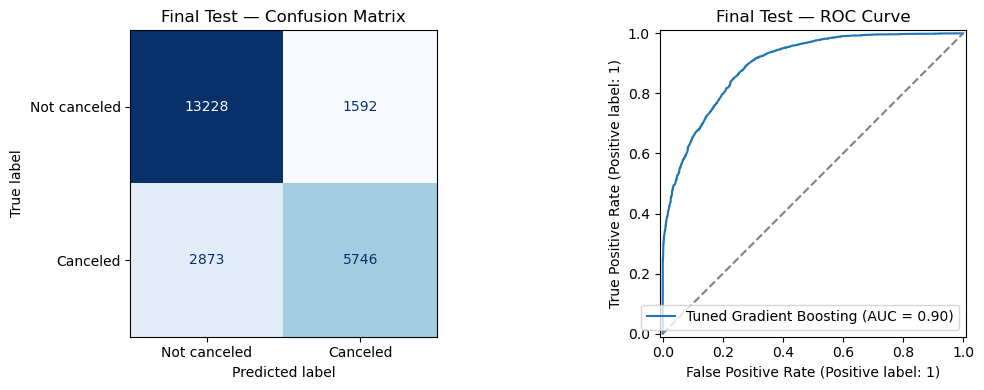

In [78]:
import matplotlib.pyplot as plt
from sklearn.metrics import ConfusionMatrixDisplay, RocCurveDisplay

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

ConfusionMatrixDisplay.from_predictions(
    y_test_revised,
    y_pred,
    labels=[0, 1],
    display_labels=["Not canceled", "Canceled"],
    cmap="Blues",
    colorbar=False,
    ax=axes[0]
)

axes[0].set_title("Final Test — Confusion Matrix")

RocCurveDisplay.from_predictions(
    y_test_revised,
    y_probability,
    ax=axes[1],
    name="Tuned Gradient Boosting"
)

axes[1].plot([0, 1], [0, 1], linestyle="--", color="gray")
axes[1].set_title("Final Test — ROC Curve")

plt.tight_layout()
plt.show()

In [79]:
import cloudpickle
from pathlib import Path

model_folder = Path("models")
model_folder.mkdir(exist_ok=True)

model_path = model_folder / "hotel_cancellation_pipeline.pkl"

model_package = {
    "pipeline": best_model,
    "input_columns": X_train_revised.columns.tolist(),
    "target": "is_canceled",
    "test_metrics": test_metrics.to_dict()
}

with model_path.open("wb") as file:
    cloudpickle.dump(model_package, file)

print("Model saved at:", model_path.resolve())

Model saved at: E:\DS13\hotel_booking_project\models\hotel_cancellation_pipeline.pkl


In [80]:
with model_path.open("rb") as file:
    loaded_package = cloudpickle.load(file)

loaded_model = loaded_package["pipeline"]
expected_columns = loaded_package["input_columns"]

print("Pipeline loaded successfully.")
print("Expected input columns:", len(expected_columns))

Pipeline loaded successfully.
Expected input columns: 23


In [81]:
sample_inputs = X_test_revised.loc[:, expected_columns].head(5)

loaded_predictions = loaded_model.predict(sample_inputs)

prediction_check = sample_inputs[["hotel", "lead_time"]].copy()

prediction_check["Actual"] = (
    y_test_revised.loc[sample_inputs.index]
)

prediction_check["Prediction"] = loaded_predictions

print(prediction_check.to_string(index=False))

assert (loaded_predictions == y_pred[:5]).all()

print("\nCheck passed: saved model predictions match.")

       hotel  lead_time  Actual  Prediction
Resort Hotel        737       0           0
Resort Hotel         13       0           0
Resort Hotel          9       0           0
Resort Hotel         75       1           1
Resort Hotel         37       0           0

Check passed: saved model predictions match.


## Conclusion

This project studied hotel booking cancellation as a binary classification
problem, with `is_canceled` as the target:
- 0: Not canceled
- 1: Canceled

The workflow included data inspection, exploratory analysis, missing-value
handling, categorical encoding, grouped validation, model comparison,
hyperparameter tuning, and held-out test evaluation.

### Model Development

Five classifiers were initially evaluated against a dummy baseline:
Logistic Regression, Decision Tree, Random Forest, Gradient Boosting,
and AdaBoost.

Gradient Boosting achieved the highest initial mean cross-validation F1
score and was selected for further development.

A subsequent feature review excluded six columns with uncertain
availability at prediction time. Identical-input groups were recalculated,
and 4,988 training rows whose revised inputs also appeared in the test set
were excluded.

The revised dataset contained:
- Training rows: 90,783
- Test rows: 23,439
- Input columns: 23

The initial model comparison used a different feature set and training
sample, so its scores are not directly comparable with the revised results.
The other classifiers were not re-evaluated on the revised inputs.

### Selected Model and Results

The final model was a Gradient Boosting classifier with:
- `n_estimators`: 150
- `max_depth`: 3
- `learning_rate`: 0.1

Four parameter combinations were evaluated using five-fold grouped
cross-validation, with F1 as the selection metric.

| Metric | Final test score |
|---|---:|
| Accuracy | 0.8095 |
| Precision | 0.7830 |
| Recall | 0.6667 |
| F1 | 0.7202 |
| ROC-AUC | 0.8963 |

The selected model achieved a mean cross-validation F1 of 0.7239.
Its held-out test F1 of 0.7202 was close to this value.

The model detected approximately two-thirds of actual cancellations.
Approximately one-third were missed, which is an important limitation.

### Limitations

- The dataset contains historical records from two hotels, so results may
  not generalize to other hotels or current booking patterns.
- The data does not establish that every retained input was available
  when a booking was first created. This is a historical classification
  study, not a validated booking-time deployment.
- Grouped splitting reduced identical-input overlap but did not evaluate
  performance on a strictly later time period.
- Engineered features explored during EDA were not included in the final
  pipeline.

### Future Work

Future improvements could include validating feature availability at a
specific prediction time, evaluating on later bookings, and choosing a
decision threshold based on the costs of missed cancellations and false
alarms.